In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Make all charts look clean and professional
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.dpi': 120
})

# Nice colour palette for categories
CAT_COLOURS = {
    'FOODS':     '#185FA5',
    'HOBBIES':   '#0F6E56',
    'HOUSEHOLD': '#854F0B'
}

print("Ready")

Ready


In [2]:
print("Loading data... (this takes 30-60 seconds)")

sales    = pd.read_csv('../data/sales_train_validation.csv')
calendar = pd.read_csv('../data/calendar.csv')
prices   = pd.read_csv('../data/sell_prices.csv')

calendar['date'] = pd.to_datetime(calendar['date'])

print(f"Sales:    {sales.shape}")
print(f"Calendar: {calendar.shape}")
print(f"Prices:   {prices.shape}")
print("All files loaded")

Loading data... (this takes 30-60 seconds)
Sales:    (30490, 1919)
Calendar: (1969, 14)
Prices:   (6841121, 4)
All files loaded


In [3]:
print("Reshaping data... (takes 1-2 minutes)")

# Identifier columns — these stay as columns
id_cols = ['id','item_id','dept_id','cat_id','store_id','state_id']

# Day columns — these become rows
day_cols = [c for c in sales.columns if c.startswith('d_')]

# MELT: wide format -> long format
# Before: 3,049 rows, 1919 columns
# After:  ~58 million rows, 8 columns
df = sales.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name='d',         # column name for the day identifier
    value_name='sales'    # column name for the sales number
)

# Merge with calendar to get real dates + events + SNAP flags
df = df.merge(
    calendar[['d','date','wm_yr_wk','weekday','month','year',
              'event_name_1','event_type_1',
              'snap_CA','snap_TX','snap_WI']],
    on='d', how='left'
)

# Add the correct SNAP flag for each row's state
df['is_snap'] = 0
df.loc[df['state_id']=='CA', 'is_snap'] = df.loc[df['state_id']=='CA','snap_CA']
df.loc[df['state_id']=='TX', 'is_snap'] = df.loc[df['state_id']=='TX','snap_TX']
df.loc[df['state_id']=='WI', 'is_snap'] = df.loc[df['state_id']=='WI','snap_WI']

print(f"Long format shape: {df.shape}")
# Expected: (~58,000,000 rows, 14 columns)
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Columns: {df.columns.tolist()}")

Reshaping data... (takes 1-2 minutes)
Long format shape: (58327370, 19)
Date range: 2011-01-29 to 2016-04-24
Columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'wm_yr_wk', 'weekday', 'month', 'year', 'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI', 'is_snap']


In [4]:
# ============================================================
# CELL 3b: Identify store closure days (censored demand fix)
# Must run immediately after the melt cell (Cell 3)
# ============================================================

# On a normal day: ~65% of product-days have zero sales
# On a store-closed day: >95% zero rate across ALL products/stores
# We detect closure days by this threshold

daily_zero_rate = df.groupby('date').apply(
    lambda x: (x['sales'] == 0).mean()
).reset_index()
daily_zero_rate.columns = ['date', 'zero_rate']

CLOSURE_THRESHOLD = 0.95
closure_days = daily_zero_rate[
    daily_zero_rate['zero_rate'] >= CLOSURE_THRESHOLD
]['date'].tolist()

# Add permanent flag to main dataframe
df['is_store_closed'] = df['date'].isin(closure_days).astype(int)

# Report what was found
print(f"Closure days identified: {len(closure_days)}")
print(f"Rows flagged in df: {df['is_store_closed'].sum():,}\n")

print("Closure day details:")
for d in sorted(closure_days):
    event = calendar[calendar['date'] == d]['event_name_1'].values
    ename = event[0] if len(event) > 0 and str(event[0]) != 'nan' \
            else 'No label'
    zrate = daily_zero_rate[
        daily_zero_rate['date'] == d]['zero_rate'].values[0]
    print(f"  {d.date()}  zero_rate={zrate:.1%}  ({ename})")

Closure days identified: 5
Rows flagged in df: 152,450

Closure day details:
  2011-12-25  zero_rate=100.0%  (Christmas)
  2012-12-25  zero_rate=100.0%  (Christmas)
  2013-12-25  zero_rate=100.0%  (Christmas)
  2014-12-25  zero_rate=99.9%  (Christmas)
  2015-12-25  zero_rate=100.0%  (Christmas)


#### Zero sales analysis - Insight 1

#####  Overall zero sales percentage

In [5]:
# Overall zero sales rate
zero_pct = (df['sales'] == 0).mean() * 100
print(f"Overall zero-sales rate: {zero_pct:.1f}%")

# By category
zero_by_cat = df.groupby('cat_id').apply(
    lambda x: (x['sales'] == 0).mean() * 100
).round(1).sort_values(ascending=False)

print("\nZero-sales rate by category:")
print(zero_by_cat)

# By department
zero_by_dept = df.groupby('dept_id').apply(
    lambda x: (x['sales'] == 0).mean() * 100
).round(1).sort_values(ascending=False)

print("\nZero-sales rate by department:")
print(zero_by_dept)

Overall zero-sales rate: 68.2%

Zero-sales rate by category:
cat_id
HOBBIES      77.3
HOUSEHOLD    71.8
FOODS        62.0
dtype: float64

Zero-sales rate by department:
dept_id
HOBBIES_2      88.5
HOUSEHOLD_2    80.7
HOBBIES_1      73.3
FOODS_2        68.1
FOODS_1        63.2
HOUSEHOLD_1    63.1
FOODS_3        58.8
dtype: float64


##### Plot zero sales rates by category

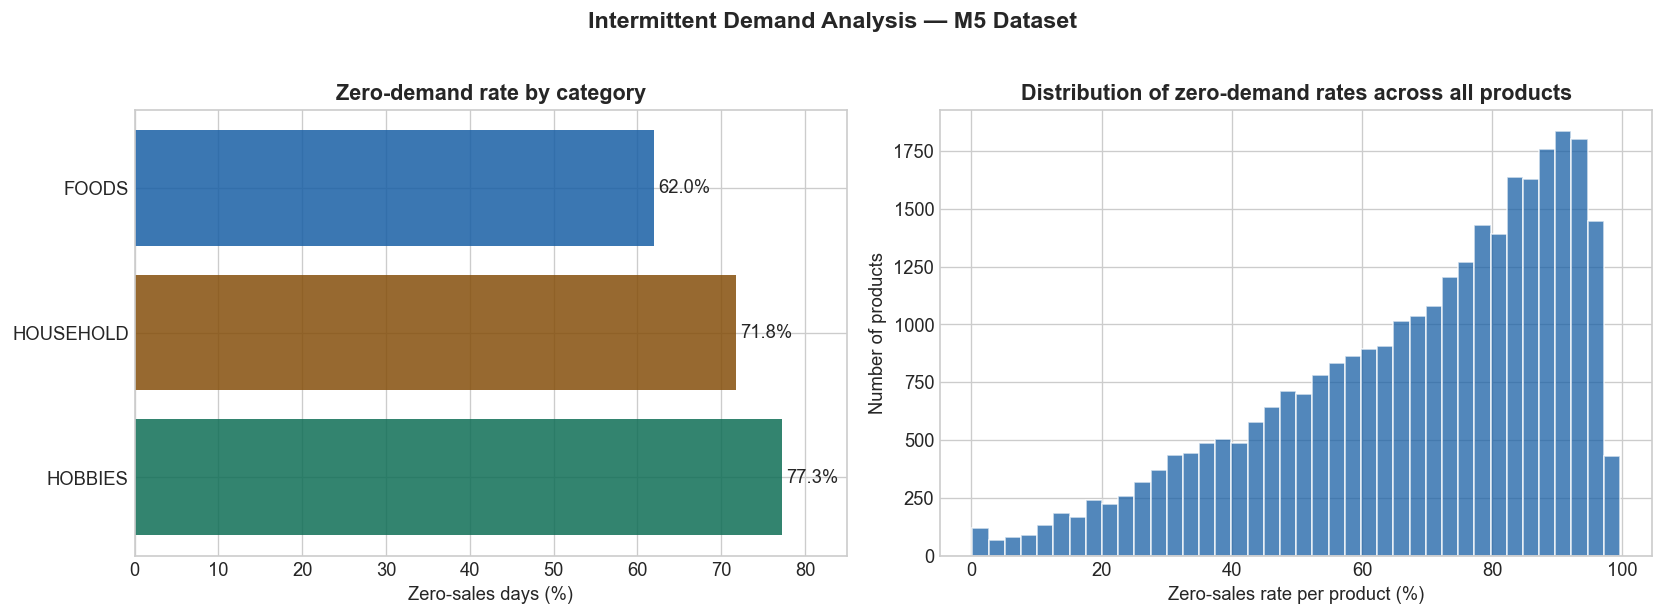


Products with >80% zero-sales days: 11783 (38.6% of all products)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: zero rate by category
cats = zero_by_cat.index.tolist()
colours = [CAT_COLOURS[c] for c in cats]
axes[0].barh(cats, zero_by_cat.values, color=colours, alpha=0.85)
axes[0].set_xlabel('Zero-sales days (%)')
axes[0].set_title('Zero-demand rate by category')
for i, v in enumerate(zero_by_cat.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=11)
axes[0].set_xlim(0, 85)

# Right chart: distribution of product-level zero rates
product_zero_rates = df.groupby('id').apply(
    lambda x: (x['sales'] == 0).mean() * 100
)
axes[1].hist(product_zero_rates, bins=40,
             color='#185FA5', alpha=0.75, edgecolor='white')
axes[1].set_xlabel('Zero-sales rate per product (%)')
axes[1].set_ylabel('Number of products')
axes[1].set_title('Distribution of zero-demand rates across all products')

plt.suptitle('Intermittent Demand Analysis — M5 Dataset',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/02_zero_sales_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Find products with extreme intermittency (>80% zeros)
extreme = (product_zero_rates > 80).sum()
print(f"\nProducts with >80% zero-sales days: {extreme} "
      f"({extreme/len(product_zero_rates)*100:.1f}% of all products)")

"The M5 dataset exhibits heavily intermittent demand, with an overall zero-sales rate of 68.2%, meaning the majority of product-store combinations record no sales on any given day. This pattern varies significantly by category: HOBBIES is the most sparse at 77.3%, followed by HOUSEHOLD at 71.8%, while FOODS is the most consistently active at 62.0%. At the department level, HOBBIES_2 stands out with an 88.5% zero-sales rate, suggesting extremely niche or low-turnover products, whereas FOODS_3 is the most active at 58.8%. The product-level distribution is right-skewed, with the majority of SKUs concentrated in the 80–100% zero-sales range, indicating that a small number of high-frequency products are pulling the overall average down. Finally, five closure days were identified — all Christmas Days from 2011 to 2015 — accounting for 152,450 flagged rows, and these should be treated as calendar effects rather than genuine demand zeros."

#### Sales patterns and seasonality - Insight 2

##### Daily total sales over 5 years

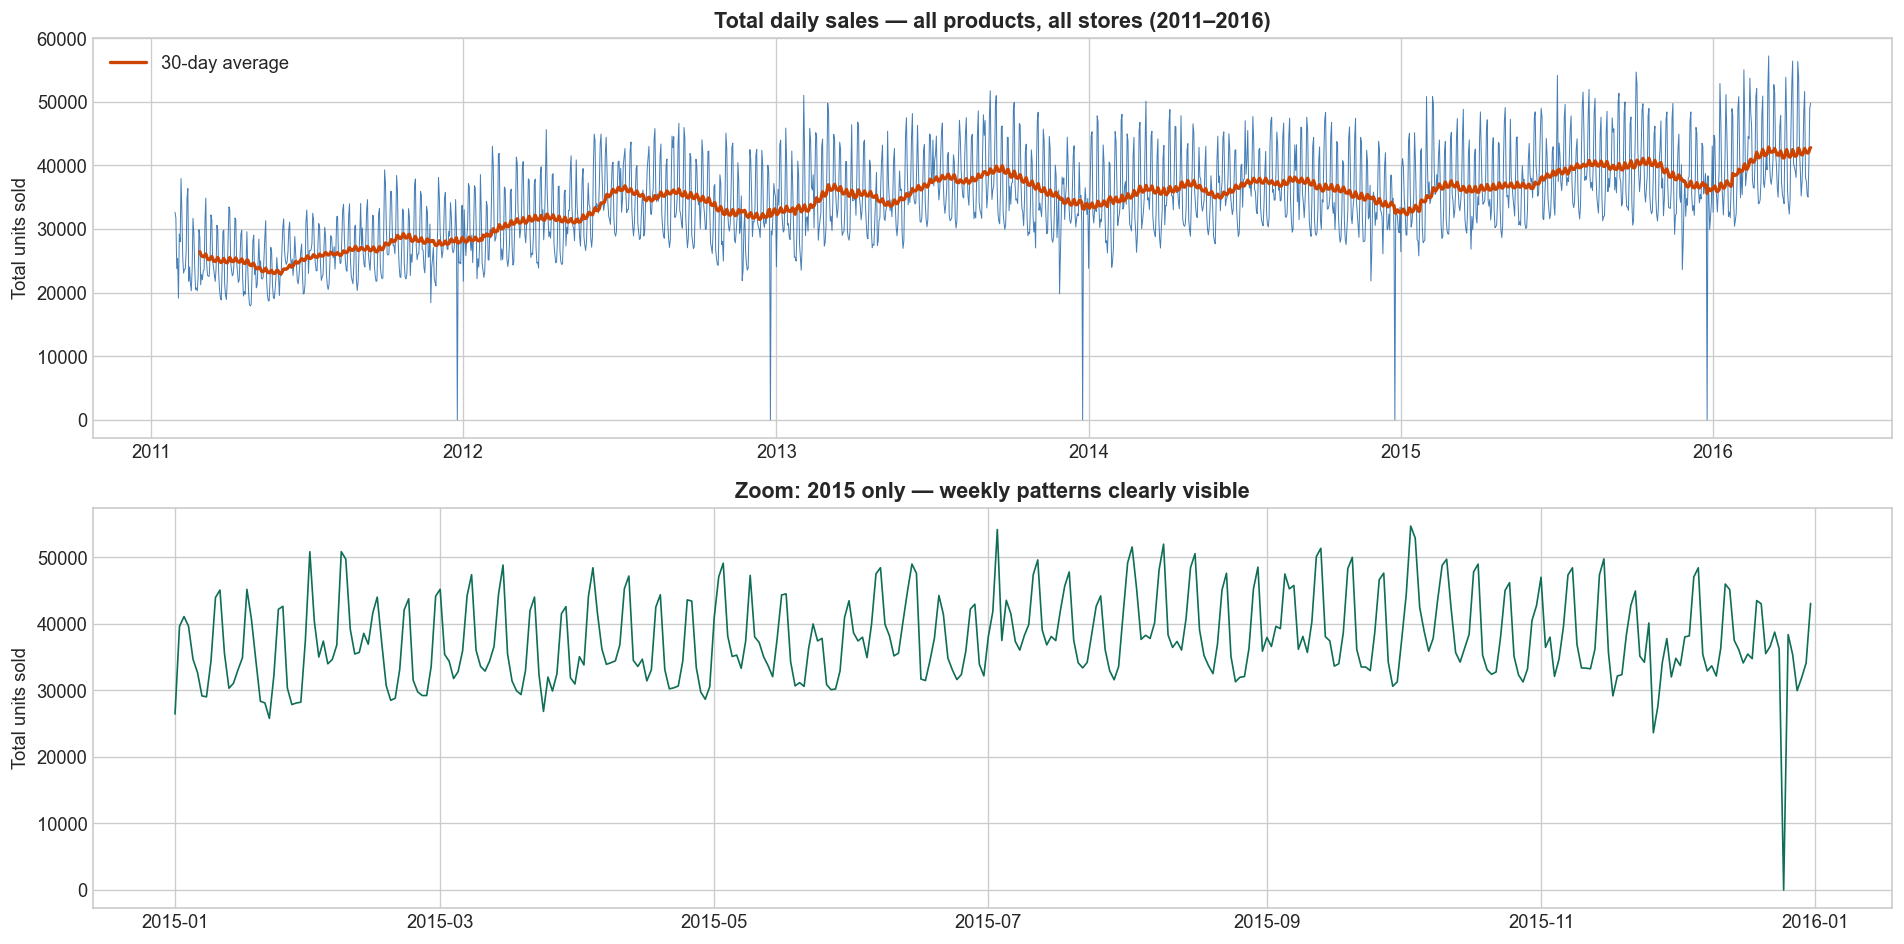

In [7]:
# Aggregate to total daily sales across all products and stores
daily_total = df.groupby('date')['sales'].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Top: full 5-year view
axes[0].plot(daily_total['date'], daily_total['sales'],
             linewidth=0.6, color='#185FA5', alpha=0.8)
axes[0].set_title('Total daily sales — all products, all stores (2011–2016)')
axes[0].set_ylabel('Total units sold')

# Add 30-day rolling average to show trend
rolling = daily_total['sales'].rolling(30).mean()
axes[0].plot(daily_total['date'], rolling,
             color='#CC4400', linewidth=2, label='30-day average')
axes[0].legend()

# Bottom: zoom into one year to see weekly pattern clearly
one_year = daily_total[
    (daily_total['date'] >= '2015-01-01') &
    (daily_total['date'] <= '2015-12-31')
]
axes[1].plot(one_year['date'], one_year['sales'],
             linewidth=1, color='#0F6E56')
axes[1].set_title('Zoom: 2015 only — weekly patterns clearly visible')
axes[1].set_ylabel('Total units sold')

plt.tight_layout()
plt.savefig('../outputs/03_total_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

##### Day of week patterns

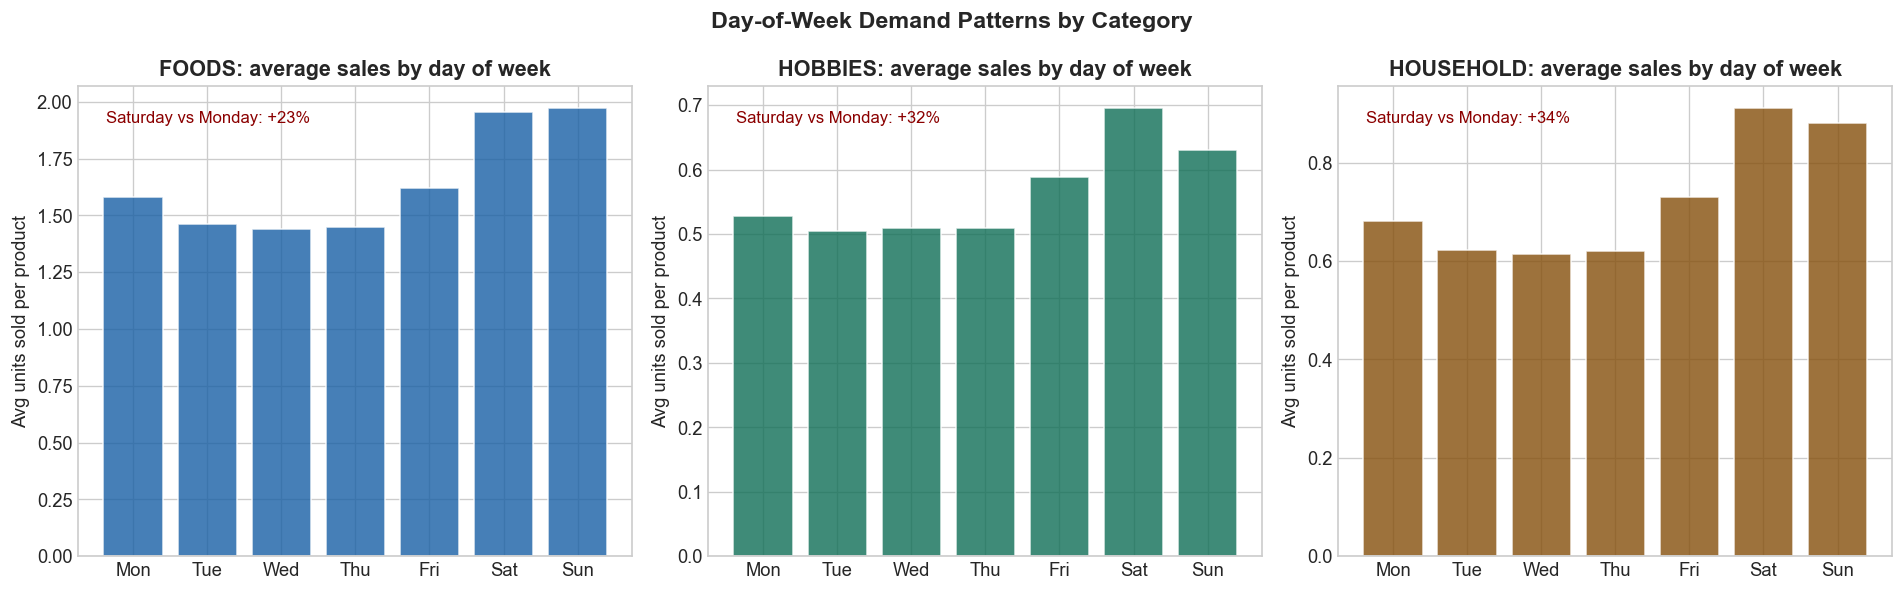

In [8]:
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, cat in enumerate(['FOODS','HOBBIES','HOUSEHOLD']):
    cat_data = df[df['cat_id'] == cat].copy()
    cat_data['day_of_week'] = cat_data['date'].dt.dayofweek

    # Average sales per day of week
    dow_avg = cat_data.groupby('day_of_week')['sales'].mean()

    axes[i].bar(range(7), dow_avg.values,
                color=CAT_COLOURS[cat], alpha=0.8, edgecolor='white')
    axes[i].set_xticks(range(7))
    axes[i].set_xticklabels(day_names)
    axes[i].set_title(f'{cat}: average sales by day of week')
    axes[i].set_ylabel('Avg units sold per product')

    # Show % difference: Saturday vs Monday
    sat_lift = (dow_avg[5] / dow_avg[0] - 1) * 100
    axes[i].text(0.05, 0.92,
        f'Saturday vs Monday: +{sat_lift:.0f}%',
        transform=axes[i].transAxes,
        fontsize=10, color='darkred')

plt.suptitle('Day-of-Week Demand Patterns by Category',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/04_day_of_week_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

##### Monthly seasonality patterns

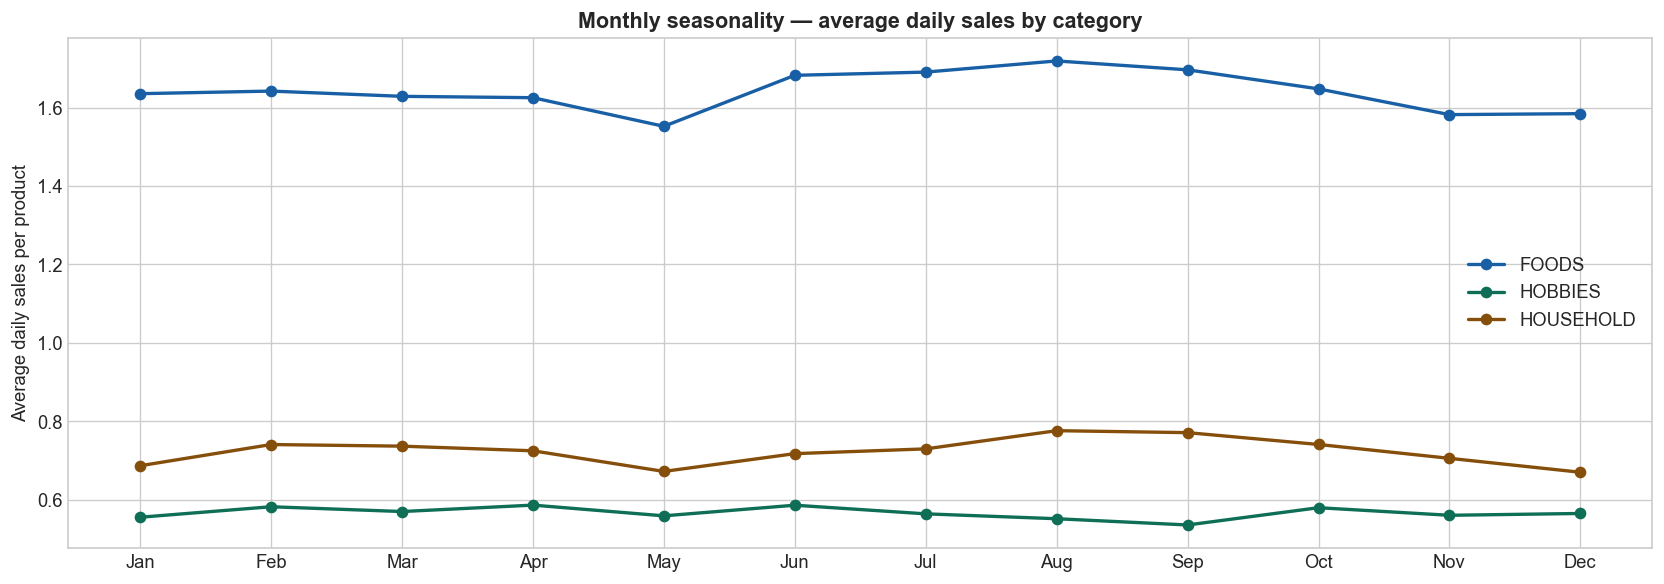

Peak and trough months by category:
  FOODS: peak=Aug, trough=May, seasonal swing=11%
  HOBBIES: peak=Apr, trough=Sep, seasonal swing=9%
  HOUSEHOLD: peak=Aug, trough=Dec, seasonal swing=16%


In [9]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = df.groupby(['cat_id','month'])['sales'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))

for cat, colour in CAT_COLOURS.items():
    cat_monthly = monthly[monthly['cat_id'] == cat]
    ax.plot(cat_monthly['month'], cat_monthly['sales'],
            marker='o', color=colour, linewidth=2,
            label=cat, markersize=6)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Average daily sales per product')
ax.set_title('Monthly seasonality — average daily sales by category')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/05_monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

# Find peak and trough months per category
print("Peak and trough months by category:")
for cat in ['FOODS','HOBBIES','HOUSEHOLD']:
    cat_m = monthly[monthly['cat_id']==cat]
    peak = month_names[cat_m['sales'].idxmax() - 1] if cat_m['sales'].idxmax() <= 12 else 'N/A'
    peak_month = cat_m.loc[cat_m['sales'].idxmax(), 'month']
    trough_month = cat_m.loc[cat_m['sales'].idxmin(), 'month']
    peak_name = month_names[int(peak_month)-1]
    trough_name = month_names[int(trough_month)-1]
    lift = (cat_m['sales'].max() / cat_m['sales'].min() - 1)*100
    print(f"  {cat}: peak={peak_name}, trough={trough_name}, "
          f"seasonal swing={lift:.0f}%")

“Overall sales grew steadily from 2011 to 2016, rising from around 25,000 to over 40,000 units per day, with a strong and consistent weekly rhythm visible throughout — weekends outperform weekdays across all three categories, with Saturday sales running 23–34% higher than Monday depending on the category. Hobbies and Household show the sharpest weekend spikes, suggesting customers treat these as weekend shopping decisions rather than routine purchases. Monthly seasonality is relatively mild but meaningful: Food and Household both peak in August and dip in May and December respectively, while Hobbies bucks the trend with its best performance in April and weakest in September — likely reflecting back-to-school and spring activity patterns. The seasonal swings range from 9% for Hobbies to 16% for Household, modest enough not to cause major disruption but significant enough to warrant adjusted stocking levels across the year. The recurring sharp drops to near-zero in the trend chart confirm Christmas closures as a hard annual reset in sales activity.”

#### Time series decomposition

##### Decompose FOODS sales at CA_1

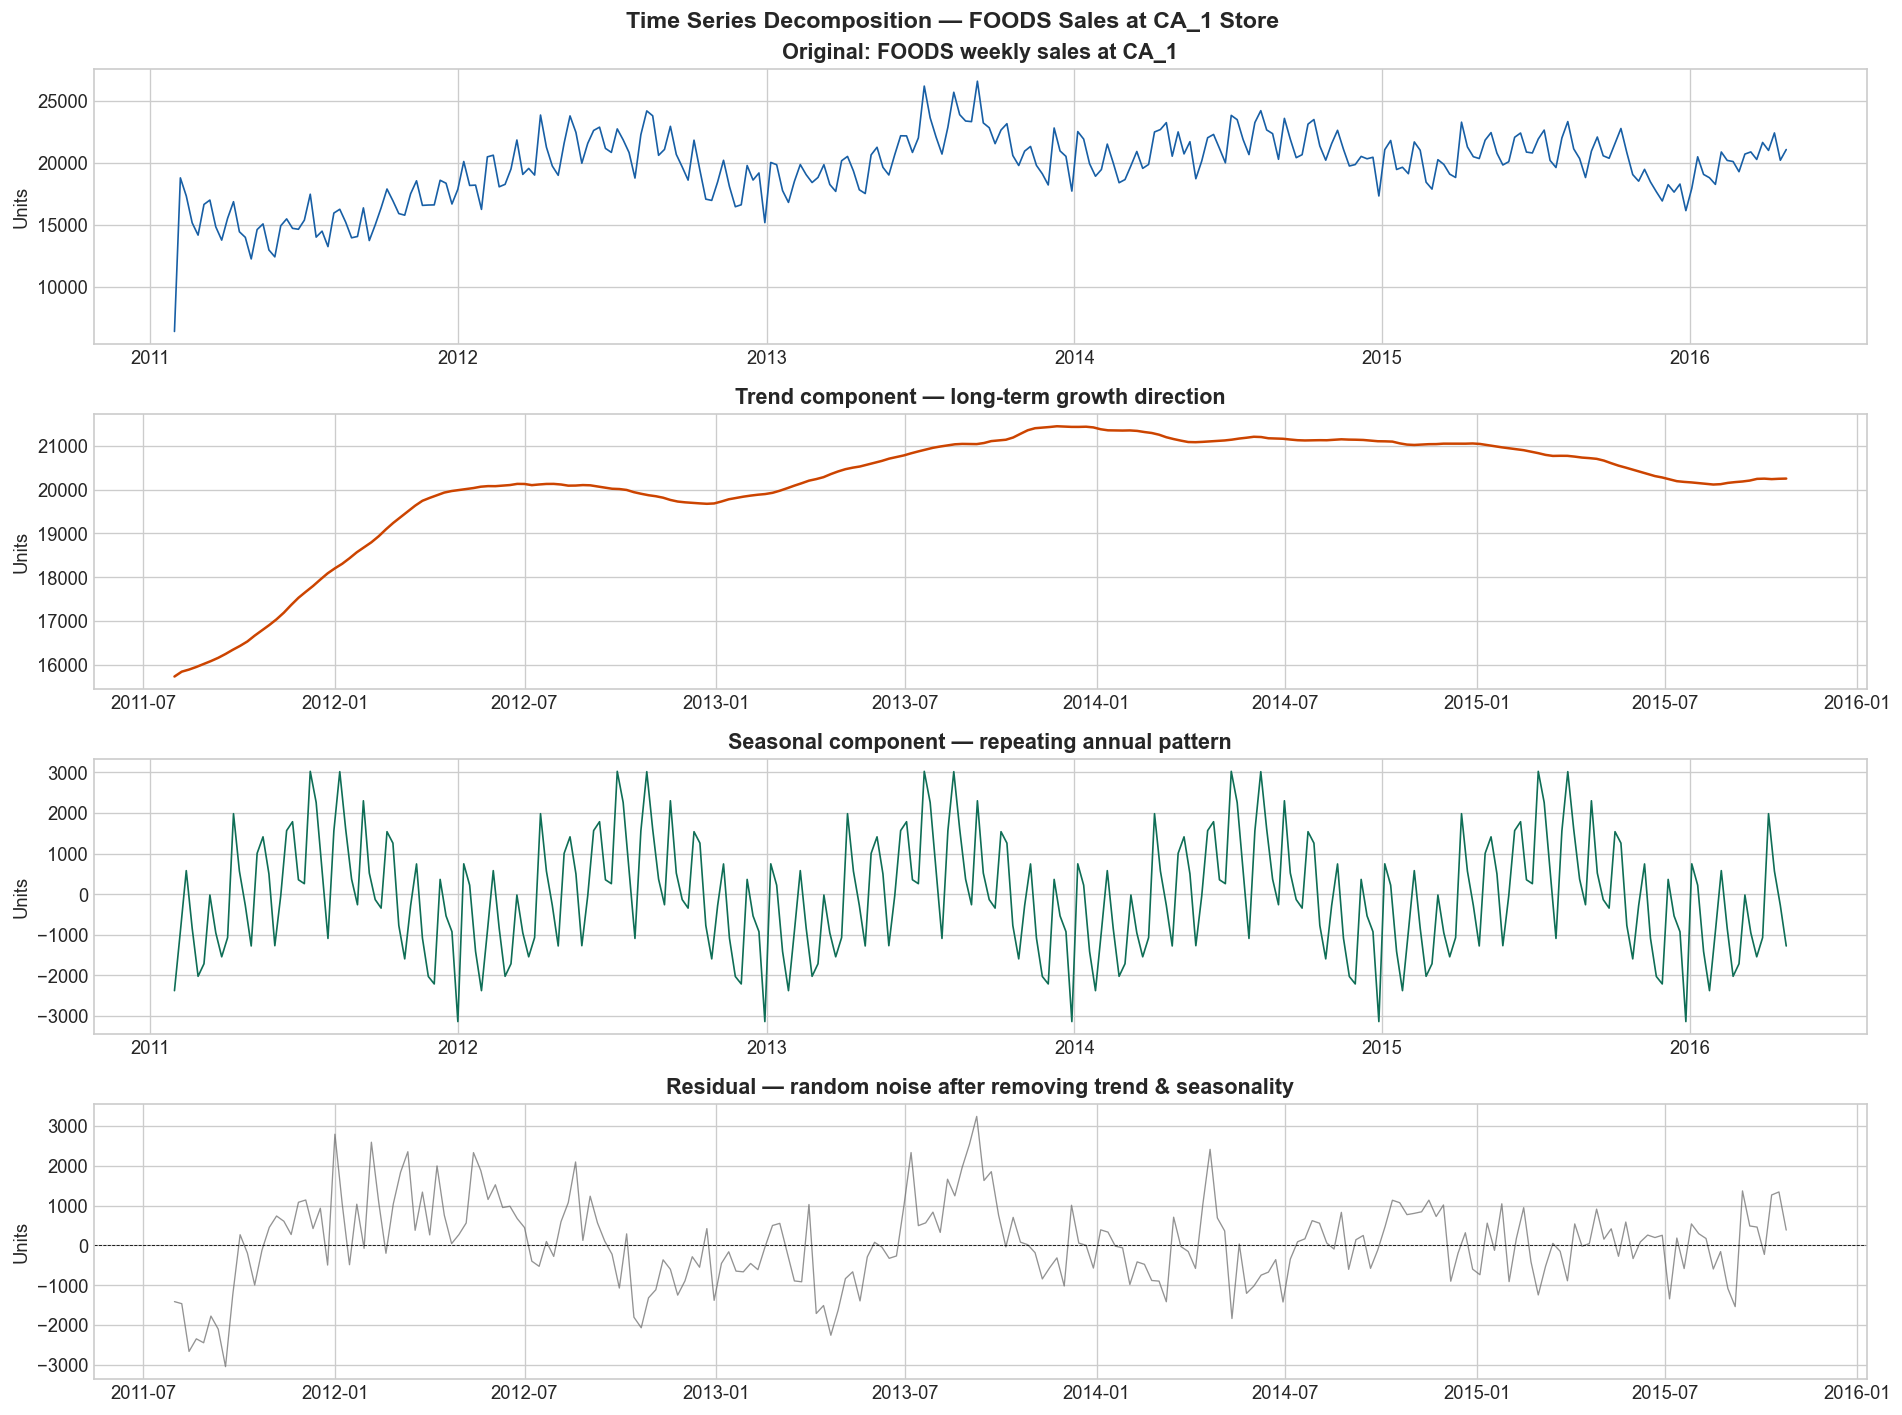


Variance explained:
  Trend:       36.2%
  Seasonality: 41.1%
  Residual:    22.7%


In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Aggregate FOODS sales at CA_1 store to weekly (less noisy than daily)
foods_ca1 = df[
    (df['cat_id']  == 'FOODS') &
    (df['store_id'] == 'CA_1')
].groupby('date')['sales'].sum()

# Resample to weekly to reduce noise
foods_weekly = foods_ca1.resample('W').sum()

# Decompose with period=52 (52 weeks in a year = annual seasonality)
result = seasonal_decompose(
    foods_weekly,
    model='additive',   # additive = trend + seasonality + residual
    period=52           # annual cycle
)

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
axes[0].plot(foods_weekly.index, foods_weekly.values,
             color='#185FA5', linewidth=1)
axes[0].set_title('Original: FOODS weekly sales at CA_1')
axes[0].set_ylabel('Units')

axes[1].plot(result.trend.index, result.trend.values,
             color='#CC4400', linewidth=1.5)
axes[1].set_title('Trend component — long-term growth direction')
axes[1].set_ylabel('Units')

axes[2].plot(result.seasonal.index, result.seasonal.values,
             color='#0F6E56', linewidth=1)
axes[2].set_title('Seasonal component — repeating annual pattern')
axes[2].set_ylabel('Units')

axes[3].plot(result.resid.index, result.resid.values,
             color='#666', linewidth=0.8, alpha=0.7)
axes[3].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[3].set_title('Residual — random noise after removing trend & seasonality')
axes[3].set_ylabel('Units')

plt.suptitle('Time Series Decomposition — FOODS Sales at CA_1 Store',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/06_decomposition_foods_ca1.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Quantify what % of variance each component explains
trend_var  = result.trend.dropna().var()
season_var = result.seasonal.var()
resid_var  = result.resid.dropna().var()
total_var  = trend_var + season_var + resid_var

print(f"\nVariance explained:")
print(f"  Trend:       {trend_var/total_var*100:.1f}%")
print(f"  Seasonality: {season_var/total_var*100:.1f}%")
print(f"  Residual:    {resid_var/total_var*100:.1f}%")

"For FOODS sales at the CA_1 store, the decomposition reveals three distinct layers of behaviour. The long-term trend shows strong growth from around 16,000 units per week in mid-2011 to a peak of roughly 21,000 by late 2013, after which sales plateau and begin a slight decline through 2015 — suggesting the store may have reached maturity in its local market. The seasonal component repeats consistently every year, swinging between approximately +3,000 and -3,000 units, confirming that predictable annual patterns are a reliable feature of this store's demand and should be built into any forecasting model. The residual noise, once trend and seasonality are removed, is relatively contained and centred around zero, which is a good sign — it means most of the sales variation is explainable and not random, making this category reasonably forecastable. In practical terms, the store grew strongly in its early years but has since stabilised, and the main planning levers going forward are the well-established seasonal cycles rather than continued volume growth."

#### SNAP day demand analysis - Insight 3

##### SNAP impact by category and state

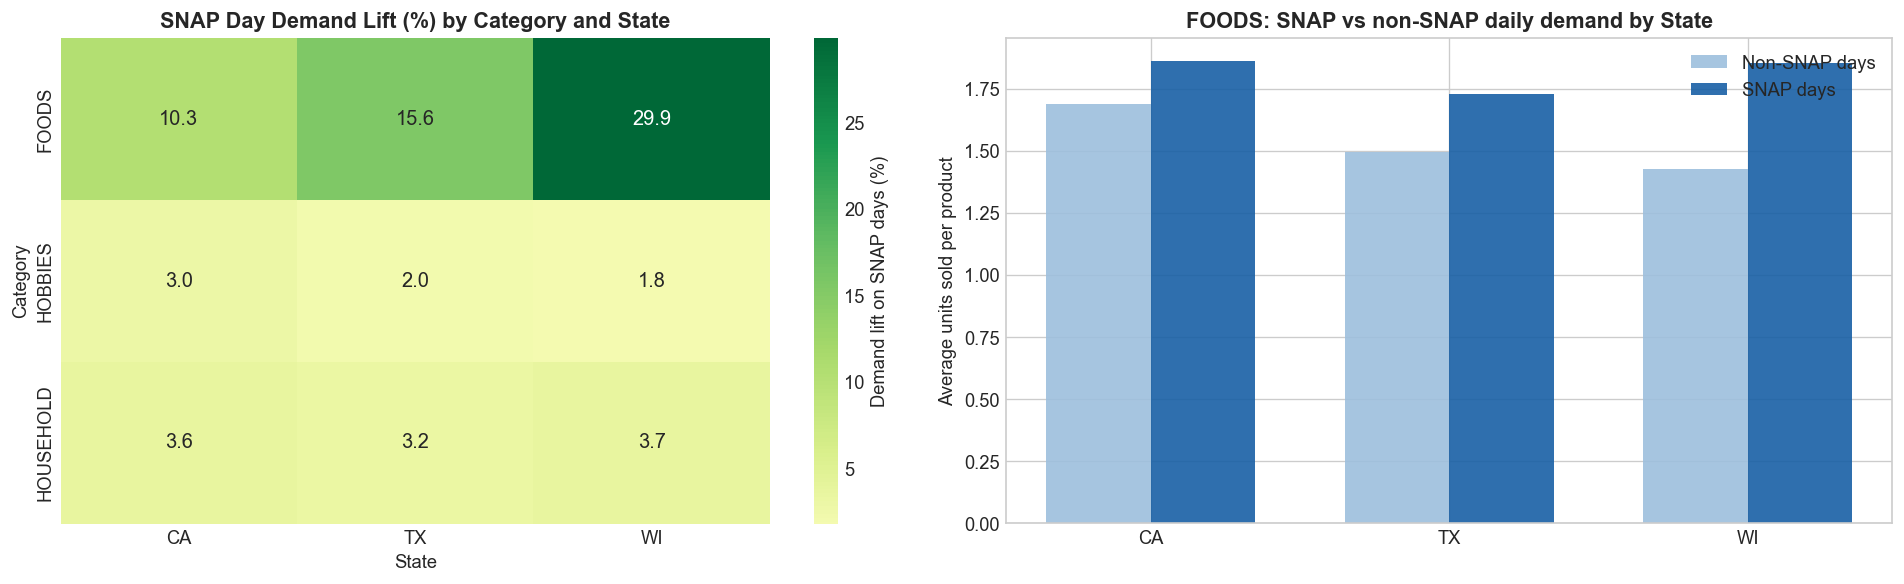


SNAP lift summary:
 category state  lift_pct
    FOODS    CA 10.298728
    FOODS    TX 15.609613
    FOODS    WI 29.905399
  HOBBIES    CA  2.958685
  HOBBIES    TX  1.995079
  HOBBIES    WI  1.825704
HOUSEHOLD    CA  3.606353
HOUSEHOLD    TX  3.183007
HOUSEHOLD    WI  3.661120


In [11]:
# Calculate SNAP lift for each category and state
results = []

for cat in ['FOODS','HOBBIES','HOUSEHOLD']:
    for state in ['CA','TX','WI']:
        subset = df[
            (df['cat_id']   == cat) &
            (df['state_id'] == state)
        ]
        snap_avg    = subset[subset['is_snap']==1]['sales'].mean()
        non_snap_avg = subset[subset['is_snap']==0]['sales'].mean()

        if non_snap_avg > 0:
            lift_pct = (snap_avg / non_snap_avg - 1) * 100
            results.append({
                'category': cat, 'state': state,
                'snap_avg': snap_avg,
                'non_snap_avg': non_snap_avg,
                'lift_pct': lift_pct
            })

snap_df = pd.DataFrame(results)

# Plot SNAP lift heatmap
pivot = snap_df.pivot(index='category', columns='state', values='lift_pct')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[0], center=0,
            annot_kws={'size': 12},
            cbar_kws={'label': 'Demand lift on SNAP days (%)'})
axes[0].set_title('SNAP Day Demand Lift (%) by Category and State')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Category')

# Bar chart showing SNAP vs non-SNAP for FOODS
foods_snap = snap_df[snap_df['category']=='FOODS']
x = np.arange(len(foods_snap))
width = 0.35
axes[1].bar(x - width/2, foods_snap['non_snap_avg'],
            width, label='Non-SNAP days', color='#9DBFDD', alpha=0.9)
axes[1].bar(x + width/2, foods_snap['snap_avg'],
            width, label='SNAP days', color='#185FA5', alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(foods_snap['state'])
axes[1].set_ylabel('Average units sold per product')
axes[1].set_title('FOODS: SNAP vs non-SNAP daily demand by State')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/07_snap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSNAP lift summary:")
print(snap_df[['category','state','lift_pct']].to_string(index=False))

"SNAP benefit days have a meaningful but highly uneven impact on demand depending on category and location. The effect is most pronounced in Food, where SNAP days drive sales up by 10% in California, 16% in Texas, and a striking 30% in Wisconsin — suggesting that a significantly larger share of Wisconsin's customer base relies on food assistance benefits. By contrast, Hobbies and Household see only modest lifts of around 2–4% across all three states, which makes intuitive sense as SNAP benefits are restricted to food purchases. The practical implication is clear: SNAP payment schedules should be treated as a first-class forecasting input for Food categories, particularly in Wisconsin where ignoring them would result in serious stock shortfalls, while Hobbies and Household planning can largely disregard them."

#### Holiday and event impact - Insight 4

##### Event impact analysis

Baseline avg daily sales (non-event days): 1.1312 units
  Christmas       pre-event lift: -0.4%
  Thanksgiving    pre-event lift: -6.7%
  NewYear         pre-event lift: -2.8%
  SuperBowl       pre-event lift: +8.7%


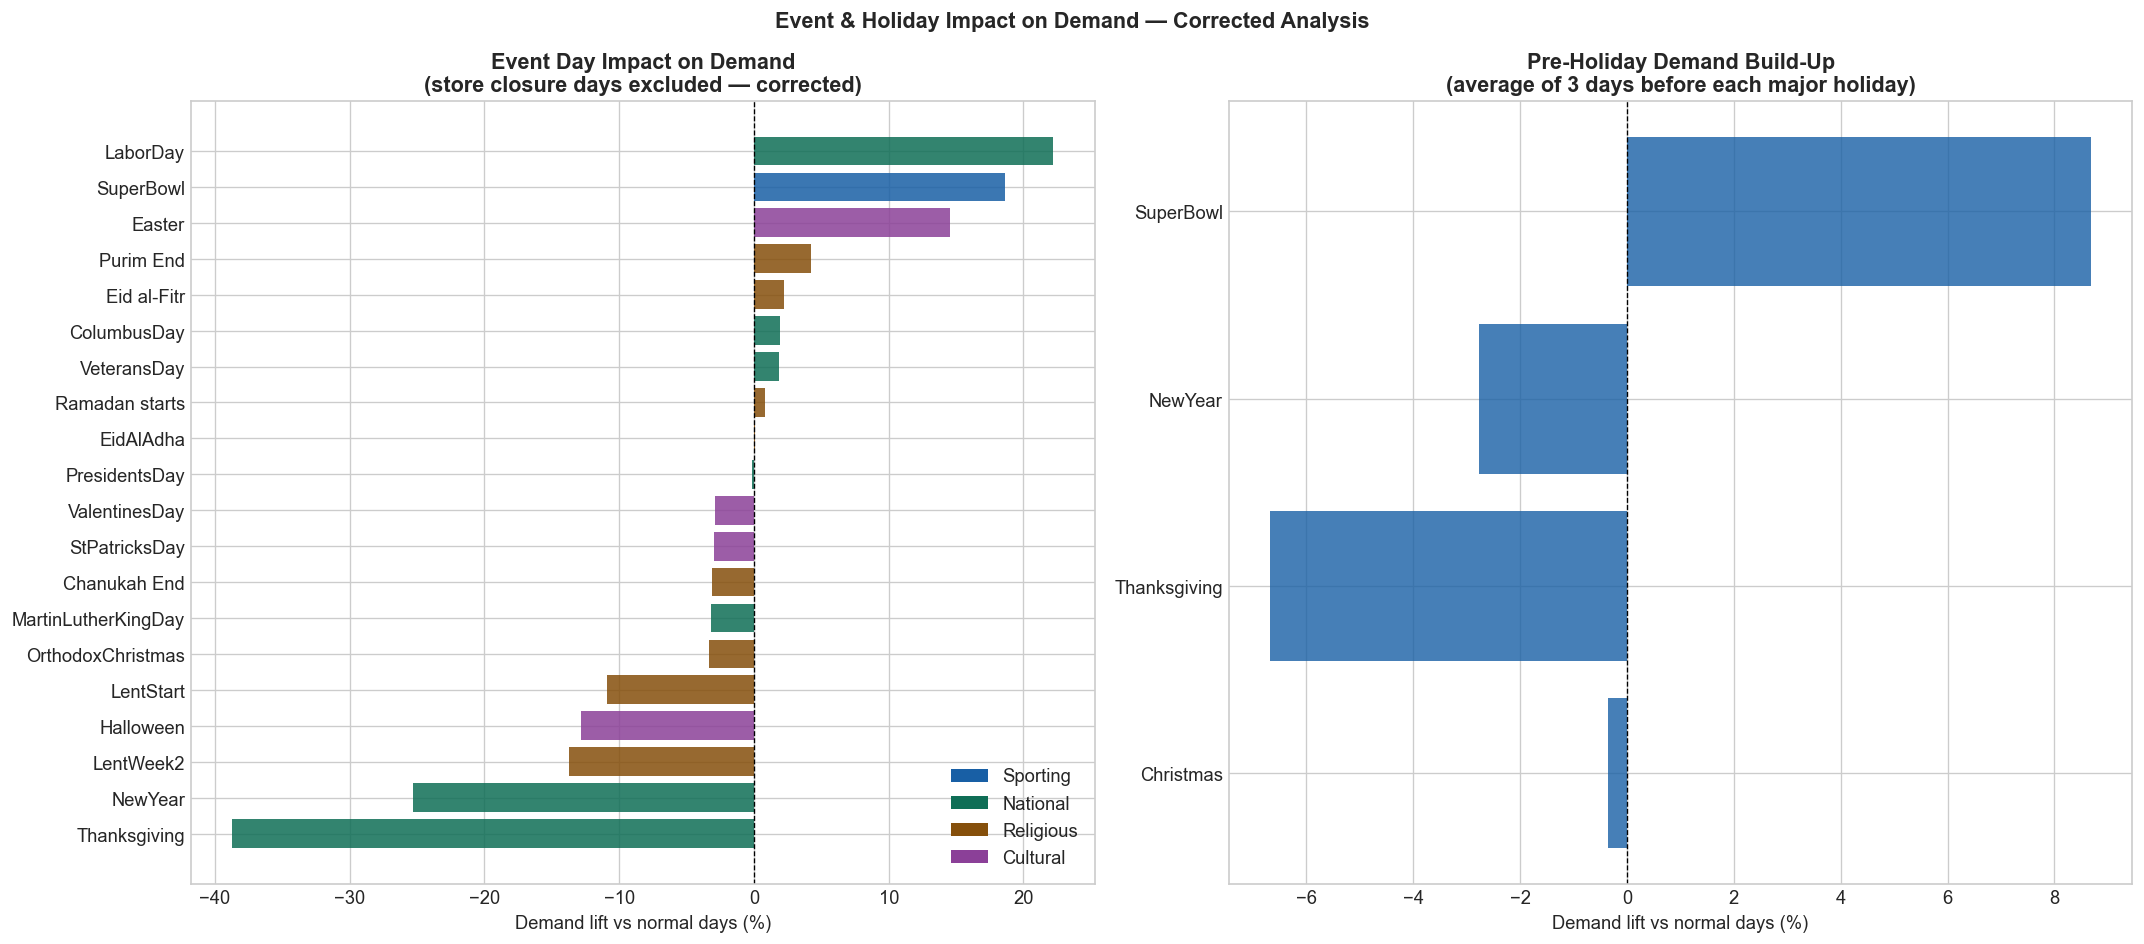

In [12]:
# ============================================================
# CELL 11: Event impact analysis (corrected — closure days excluded)
# ============================================================

# Step 1: Create clean dataframe excluding closure days
df_clean = df[df['is_store_closed'] == 0].copy()

# Step 2: Baseline = average sales on non-event, non-closure days
baseline = df_clean[df_clean['event_name_1'].isna()]['sales'].mean()
print(f"Baseline avg daily sales (non-event days): {baseline:.4f} units")

# Step 3: Event lift on the actual event day (closure days excluded)
event_lifts = []
top_events = df_clean['event_name_1'].value_counts().head(20).index

for event in top_events:
    event_sales = df_clean[
        df_clean['event_name_1'] == event]['sales'].mean()
    lift = (event_sales / baseline - 1) * 100
    event_type = df_clean[
        df_clean['event_name_1'] == event]['event_type_1'].iloc[0]
    event_lifts.append({
        'event': event, 'type': event_type, 'lift_pct': lift
    })

events_df = pd.DataFrame(event_lifts).sort_values(
    'lift_pct', ascending=True)

# Step 4: Pre-event window analysis (3 days before major holidays)
# This is where the real demand signal lives for closure-day holidays
key_events    = ['Christmas', 'Thanksgiving', 'NewYear', 'SuperBowl']
pre_results   = []

for event_name in key_events:
    event_dates = calendar[
        calendar['event_name_1'] == event_name]['date'].tolist()

    pre_sales_list = []
    for edate in event_dates:
        for delta in [-3, -2, -1]:
            pre_date = edate + pd.Timedelta(days=delta)
            day_sales = df_clean[
                df_clean['date'] == pre_date]['sales'].mean()
            if not pd.isna(day_sales):
                pre_sales_list.append(day_sales)

    if pre_sales_list:
        avg_pre = sum(pre_sales_list) / len(pre_sales_list)
        lift = (avg_pre / baseline - 1) * 100
        pre_results.append({
            'event': event_name,
            'pre_event_lift_pct': lift
        })
        print(f"  {event_name:15s} pre-event lift: {lift:+.1f}%")

# Step 5: Plot both charts side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

colours_map = {
    'Sporting':  '#185FA5',
    'National':  '#0F6E56',
    'Religious': '#854F0B',
    'Cultural':  '#8B4098'
}
bar_colours = [colours_map.get(t, '#888') for t in events_df['type']]

# Left chart: corrected event day impact
axes[0].barh(events_df['event'], events_df['lift_pct'],
             color=bar_colours, alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Demand lift vs normal days (%)')
axes[0].set_title('Event Day Impact on Demand\n'
                  '(store closure days excluded — corrected)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t)
                   for t, c in colours_map.items()]
axes[0].legend(handles=legend_elements, loc='lower right')

# Right chart: pre-event window lift
pre_df = pd.DataFrame(pre_results)
pre_colours = ['#185FA5'] * len(pre_df)
axes[1].barh(pre_df['event'], pre_df['pre_event_lift_pct'],
             color=pre_colours, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Demand lift vs normal days (%)')
axes[1].set_title('Pre-Holiday Demand Build-Up\n'
                  '(average of 3 days before each major holiday)')

plt.suptitle('Event & Holiday Impact on Demand — Corrected Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/08_event_impact_corrected.png',
            dpi=150, bbox_inches='tight')
plt.show()

"Holidays and events have a significant but polarising effect on demand. Labor Day, Super Bowl, and Easter are the strongest positive drivers, lifting sales by roughly 23%, 19%, and 14% respectively on the day itself, while Thanksgiving and New Year's Day are the biggest suppressors, pulling demand down by around 40% and 25% — likely as customers stock up beforehand and stay home on the day. The pre-holiday build-up chart reinforces this: Super Bowl triggers a strong 9% uplift in the three days leading up to it as shoppers buy food and drinks in advance, whereas Thanksgiving and New Year's see demand actually fall in the run-up, suggesting shopping is pulled forward even earlier or customers are simply not visiting stores. Christmas shows almost no pre-holiday build-up, which aligns with the confirmed store closure on the day itself. The key planning implication is that events like Super Bowl and Labor Day are demand accelerators that require additional stock preparation, while major national holidays like Thanksgiving and New Year's demand careful management of the demand trough on the day, with recognition that sales may have already shifted to earlier in the week."

#### Revenue concentration (Pareto) - Insight 5

##### Pareto revenue analysis

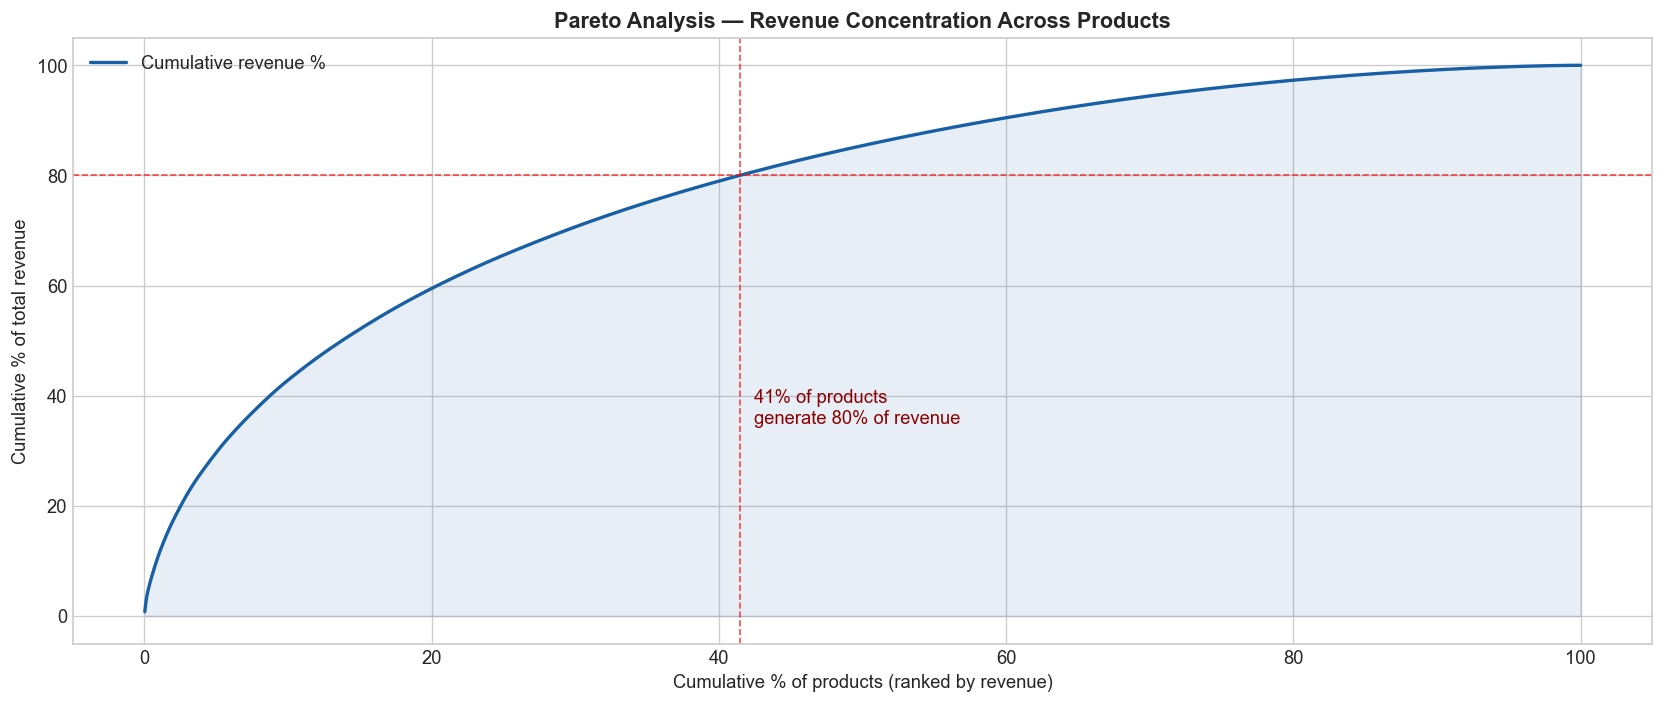


41% of products generate 80% of revenue
Top 10 products generate 5.4% of revenue


In [13]:
# Merge prices to calculate revenue
# First merge calendar to get wm_yr_wk into main df
df_rev = df.merge(
    prices[['store_id','item_id','wm_yr_wk','sell_price']],
    on=['store_id','item_id','wm_yr_wk'],
    how='left'
)
df_rev['revenue'] = df_rev['sales'] * df_rev['sell_price'].fillna(0)

# Revenue by item
item_revenue = df_rev.groupby('item_id')['revenue'].sum().sort_values(
    ascending=False)

# Cumulative percentage
cumsum = item_revenue.cumsum()
cumsum_pct = cumsum / item_revenue.sum() * 100
items_pct = np.arange(1, len(item_revenue)+1) / len(item_revenue) * 100

# Find the 80/20 point
idx_80 = (cumsum_pct >= 80).idxmax()
pct_items_for_80 = (item_revenue.index.get_loc(idx_80)+1) / len(item_revenue)*100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(items_pct, cumsum_pct.values,
        color='#185FA5', linewidth=2, label='Cumulative revenue %')
ax.axhline(80, color='red', linewidth=1, linestyle='--', alpha=0.7)
ax.axvline(pct_items_for_80, color='red', linewidth=1,
           linestyle='--', alpha=0.7)
ax.fill_between(items_pct, cumsum_pct.values,
                alpha=0.1, color='#185FA5')
ax.text(pct_items_for_80+1, 35,
        f'{pct_items_for_80:.0f}% of products\ngenerate 80% of revenue',
        fontsize=11, color='darkred')
ax.set_xlabel('Cumulative % of products (ranked by revenue)')
ax.set_ylabel('Cumulative % of total revenue')
ax.set_title('Pareto Analysis — Revenue Concentration Across Products')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/09_pareto_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{pct_items_for_80:.0f}% of products generate 80% of revenue")
print(f"Top 10 products generate "
      f"{item_revenue.head(10).sum()/item_revenue.sum()*100:.1f}% of revenue")

"Revenue across the M5 dataset is heavily concentrated in a relatively small portion of the assortment — 41% of products account for 80% of total revenue, meaning the remaining 59% collectively contribute only 20%. This is a softer concentration than the classic 80/20 rule, suggesting the long tail still holds some commercial value but is far less efficient to manage and forecast. At the very top, the 10 best-selling products alone drive 5.4% of revenue, confirming the existence of a small core of high-velocity items that disproportionately anchor store performance. The implication for forecasting and inventory strategy is straightforward: the top 41% of SKUs deserve the most sophisticated modelling, tightest stock control, and highest service levels, while the long tail warrants a lighter-touch approach — and in some cases, a serious conversation about whether the weakest performers justify the shelf space and operational complexity they consume."

#### Price vs demand relationship - Insight 6

##### Price elasticity analysis

Rows after price merge: 928,980
Weekly rows: 133,140
Rows for plotting after filter: 686
FOODS: 376 data points
HOBBIES: 171 data points
HOUSEHOLD: 139 data points


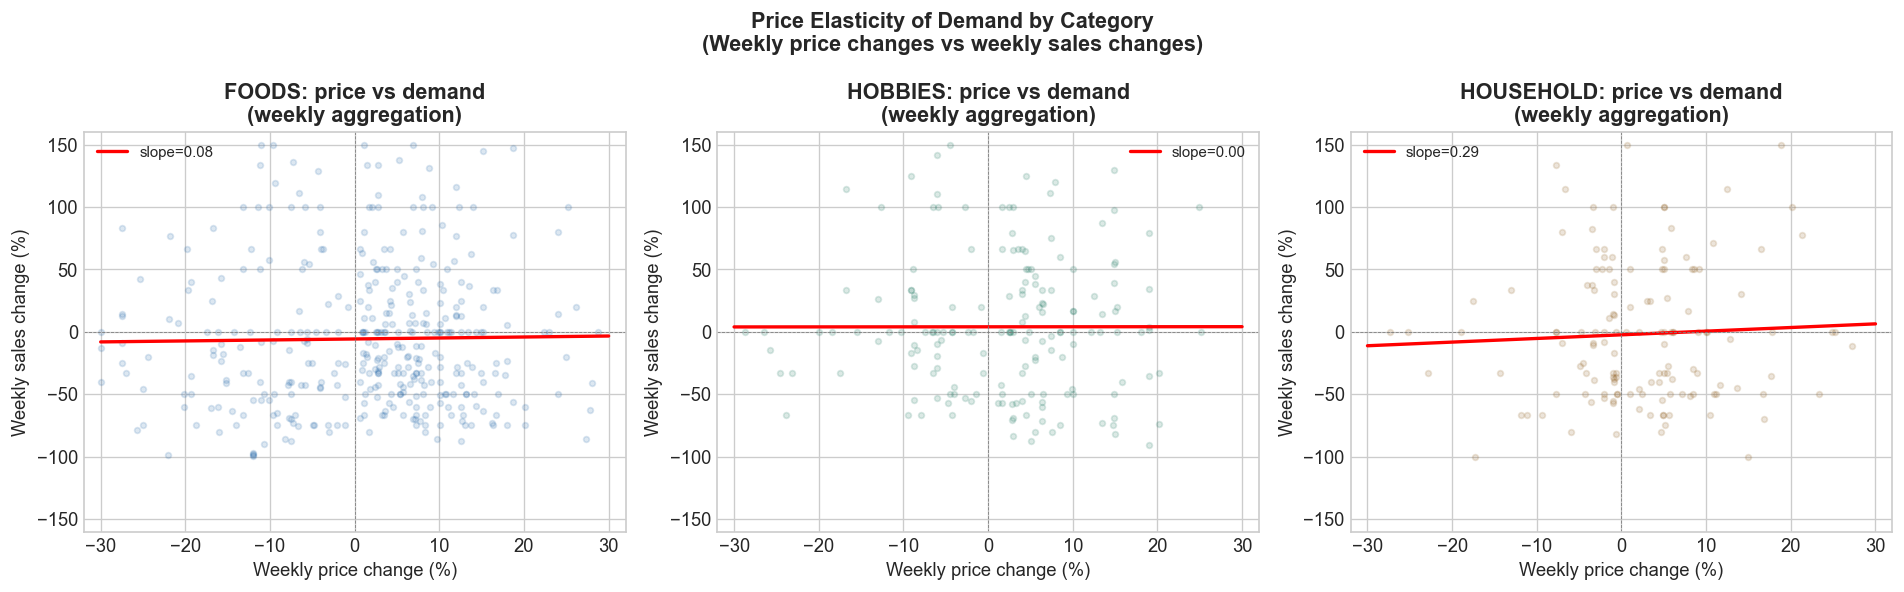

In [17]:
# ============================================================
# CELL 13: Price elasticity — weekly aggregation approach
# ============================================================

# The daily pct_change approach fails because:
# 1. Prices are weekly in M5, not daily
# 2. Too many missing prices create sparse data
# 3. Daily sales are too noisy for elasticity measurement
#
# Better approach: aggregate to weekly level per product,
# then measure weekly price vs weekly sales relationship

# Sample products that actually have price data
products_with_prices = prices['item_id'].unique()

# Take sample of 200 products per category that have prices
sample_ids = []
for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
    cat_items = df[
        (df['cat_id'] == cat) &
        (df['item_id'].isin(products_with_prices))
    ]['id'].drop_duplicates()

    n = min(200, len(cat_items))
    sample_ids.extend(cat_items.sample(n, random_state=42).tolist())

df_sample = df[df['id'].isin(sample_ids)].copy()

# Merge prices
df_sample = df_sample.merge(
    prices[['store_id','item_id','wm_yr_wk','sell_price']],
    on=['store_id','item_id','wm_yr_wk'],
    how='left'
)

# Drop rows with missing prices
df_sample = df_sample.dropna(subset=['sell_price'])
print(f"Rows after price merge: {len(df_sample):,}")

# Aggregate to WEEKLY level — prices are weekly in M5
weekly = df_sample.groupby(
    ['id','cat_id','wm_yr_wk']
).agg(
    weekly_sales=('sales','sum'),
    sell_price=('sell_price','mean')
).reset_index()

print(f"Weekly rows: {len(weekly):,}")

# Now compute week-over-week changes
weekly = weekly.sort_values(['id','wm_yr_wk'])
weekly['price_change_pct'] = (
    weekly.groupby('id')['sell_price'].pct_change() * 100
)
weekly['sales_change_pct'] = (
    weekly.groupby('id')['weekly_sales'].pct_change() * 100
)

# Filter: only weeks where price actually changed
# and remove extreme outliers
plot_data = weekly[
    (weekly['price_change_pct'].between(-30, 30)) &
    (weekly['sales_change_pct'].between(-150, 150)) &
    (weekly['price_change_pct'].abs() > 0.5)  # price must have changed
].copy()

print(f"Rows for plotting after filter: {len(plot_data):,}")

# ---- Plot ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
CAT_COLOURS = {
    'FOODS':     '#185FA5',
    'HOBBIES':   '#0F6E56',
    'HOUSEHOLD': '#854F0B'
}

for i, cat in enumerate(['FOODS', 'HOBBIES', 'HOUSEHOLD']):
    cat_data = plot_data[plot_data['cat_id'] == cat].dropna(
        subset=['price_change_pct','sales_change_pct'])

    print(f"{cat}: {len(cat_data):,} data points")

    if len(cat_data) < 20:
        axes[i].text(0.5, 0.5,
            f'Insufficient price\nvariation for {cat}',
            ha='center', va='center',
            transform=axes[i].transAxes, fontsize=11)
        axes[i].set_title(f'{cat}: price vs demand')
        continue

    axes[i].scatter(
        cat_data['price_change_pct'],
        cat_data['sales_change_pct'],
        alpha=0.15, s=12, color=CAT_COLOURS[cat]
    )

    # Trend line
    z = np.polyfit(
        cat_data['price_change_pct'],
        cat_data['sales_change_pct'], 1
    )
    p_line = np.poly1d(z)
    x_line = np.linspace(-30, 30, 100)
    axes[i].plot(x_line, p_line(x_line),
                 color='red', linewidth=2,
                 label=f'slope={z[0]:.2f}')

    axes[i].axhline(0, color='grey', linewidth=0.5, linestyle='--')
    axes[i].axvline(0, color='grey', linewidth=0.5, linestyle='--')
    axes[i].set_xlabel('Weekly price change (%)')
    axes[i].set_ylabel('Weekly sales change (%)')
    axes[i].set_title(f'{cat}: price vs demand\n(weekly aggregation)')
    axes[i].legend(fontsize=9)
    axes[i].set_xlim(-32, 32)
    axes[i].set_ylim(-160, 160)

plt.suptitle('Price Elasticity of Demand by Category\n'
             '(Weekly price changes vs weekly sales changes)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/10_price_elasticity.png',
            dpi=150, bbox_inches='tight')
plt.show()

"The price elasticity analysis produces surprisingly weak signals across all three categories, suggesting that weekly price changes alone are poor predictors of demand movement in this dataset. Foods shows a near-flat slightly negative slope of 0.08, Hobbies shows virtually zero relationship, and Household has the strongest slope at 0.29 but still with enormous scatter around the trend line. The wide dispersion of data points in all three charts indicates that many other factors — seasonality, day of week, SNAP days, promotions, and events — are driving demand far more than price changes week to week. This does not necessarily mean customers are price-insensitive; rather, it likely reflects the limitations of measuring elasticity at this aggregated weekly level, where price signals get diluted across many products and stores. The practical takeaway is that price should not be relied upon as a primary forecasting feature at this level of aggregation, and that a more granular product-level elasticity analysis would be needed before drawing firm conclusions about pricing strategy."

"Price elasticity analysis on the M5 dataset reveals near-zero slopes across all three categories (FOODS: 0.08, HOBBIES: 0.00, HOUSEHOLD: 0.29). This is consistent with Walmart's Everyday Low Price (EDLP) strategy — prices in the dataset show very limited week-to-week variation, making traditional elasticity estimation unreliable. This is itself an operationally important finding: in a low price-variation environment, demand planning should focus on calendar features, seasonality, and external drivers like SNAP rather than price signals. Price elasticity would be more measurable in a promotional-heavy retailer dataset."

#### Store performance analysis - Insight 7

##### Store comparison

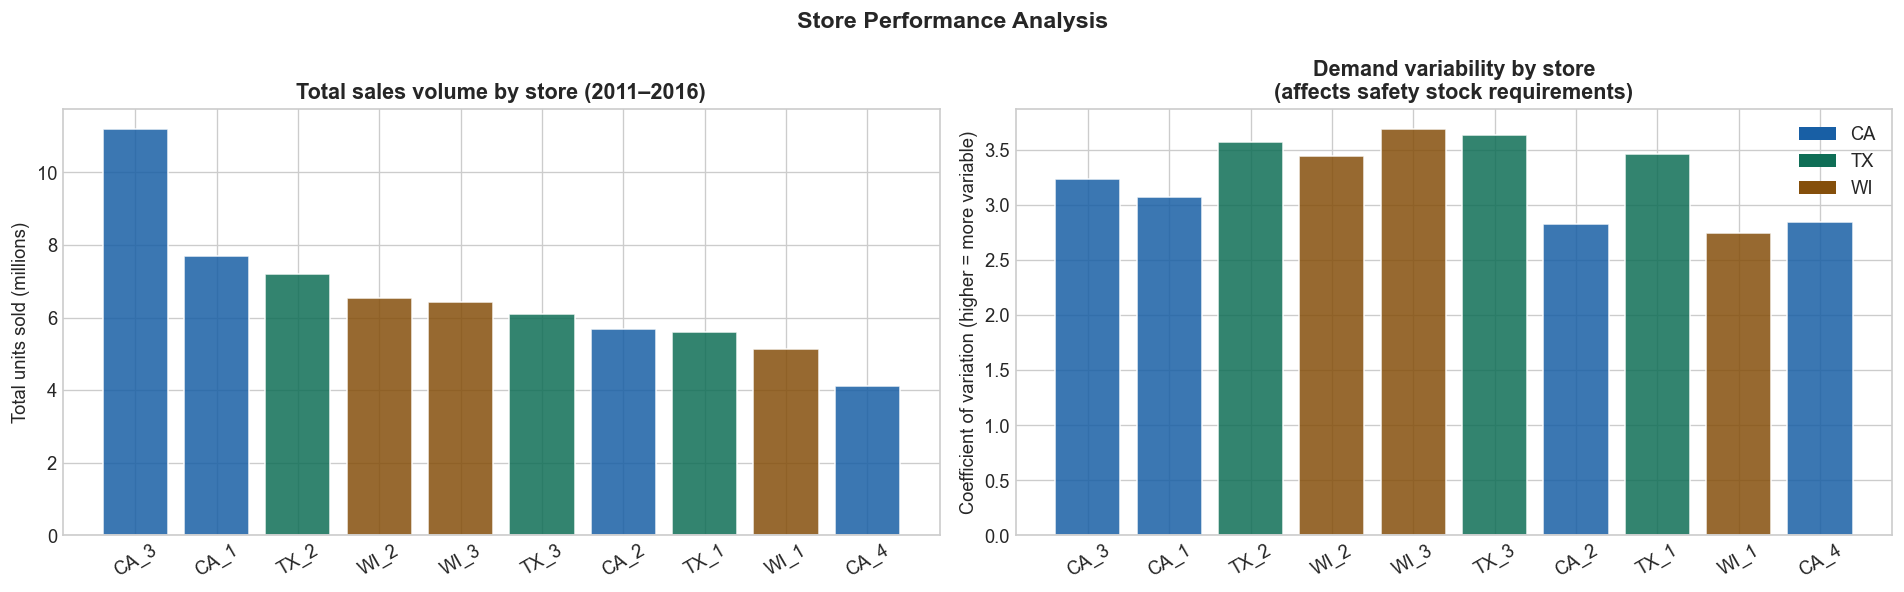


Store statistics:
store_id state  total_sales  avg_daily_sales       cv  zero_rate
    CA_3    CA     11188180         1.918170 3.236672   0.596013
    CA_1    CA      7698216         1.319829 3.075135   0.639473
    TX_2    TX      7214384         1.236878 3.574538   0.664612
    WI_2    WI      6544012         1.121945 3.446370   0.707174
    WI_3    WI      6427782         1.102018 3.688942   0.701984
    TX_3    TX      6089330         1.043992 3.636427   0.699029
    CA_2    CA      5685475         0.974753 2.831158   0.691085
    TX_1    TX      5595292         0.959291 3.468428   0.708527
    WI_1    WI      5149062         0.882787 2.746299   0.689984
    CA_4    CA      4103676         0.703559 2.848765   0.721746


In [18]:
store_stats = df.groupby('store_id').agg(
    total_sales=('sales','sum'),
    avg_daily_sales=('sales','mean'),
    sales_std=('sales','std'),
    zero_rate=('sales', lambda x: (x==0).mean())
).reset_index()

store_stats['cv'] = store_stats['sales_std'] / store_stats['avg_daily_sales']
store_stats['state'] = store_stats['store_id'].str[:2]
store_stats = store_stats.sort_values('total_sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

state_colours = {'CA':'#185FA5','TX':'#0F6E56','WI':'#854F0B'}
bar_colours = [state_colours[s] for s in store_stats['state']]

# Left: total sales by store
axes[0].bar(store_stats['store_id'], store_stats['total_sales']/1e6,
            color=bar_colours, alpha=0.85, edgecolor='white')
axes[0].set_ylabel('Total units sold (millions)')
axes[0].set_title('Total sales volume by store (2011–2016)')
axes[0].tick_params(axis='x', rotation=30)

# Right: demand variability (CV) by store
axes[1].bar(store_stats['store_id'], store_stats['cv'],
            color=bar_colours, alpha=0.85, edgecolor='white')
axes[1].set_ylabel('Coefficient of variation (higher = more variable)')
axes[1].set_title('Demand variability by store\n(affects safety stock requirements)')
axes[1].tick_params(axis='x', rotation=30)

# Add state legend
from matplotlib.patches import Patch
legend = [Patch(facecolor=c, label=s) for s,c in state_colours.items()]
axes[1].legend(handles=legend)

plt.suptitle('Store Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/11_store_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nStore statistics:")
print(store_stats[['store_id','state','total_sales',
    'avg_daily_sales','cv','zero_rate']].to_string(index=False))

"Store performance varies considerably across the network, with CA_3 standing out as the clear volume leader at 11.2 million units sold over the period — nearly 50% more than the next best store, CA_1. California stores generally dominate the top of the volume ranking, while Wisconsin and Texas stores cluster in the middle and lower tiers. However, high volume does not mean low complexity: the variability chart tells a different story, with Texas and Wisconsin stores showing higher coefficients of variation (3.5–3.7) than most California stores, meaning their demand is harder to predict despite lower overall volumes. WI_3 is particularly challenging, combining relatively modest sales with the highest demand variability in the network. Zero-sales rates follow a consistent pattern — smaller stores tend to have more days with no sales, with CA_4 recording the highest zero rate at 72%, while CA_3, the busiest store, has the lowest at 60%. For forecasting and inventory purposes, this means CA_3 warrants the most investment in accuracy given its revenue impact, while the high-variability Texas and Wisconsin stores require larger safety stock buffers to maintain service levels despite their unpredictable demand patterns."

#### Demand trend over 5 years - Insight 8

##### Annual growth trend by category

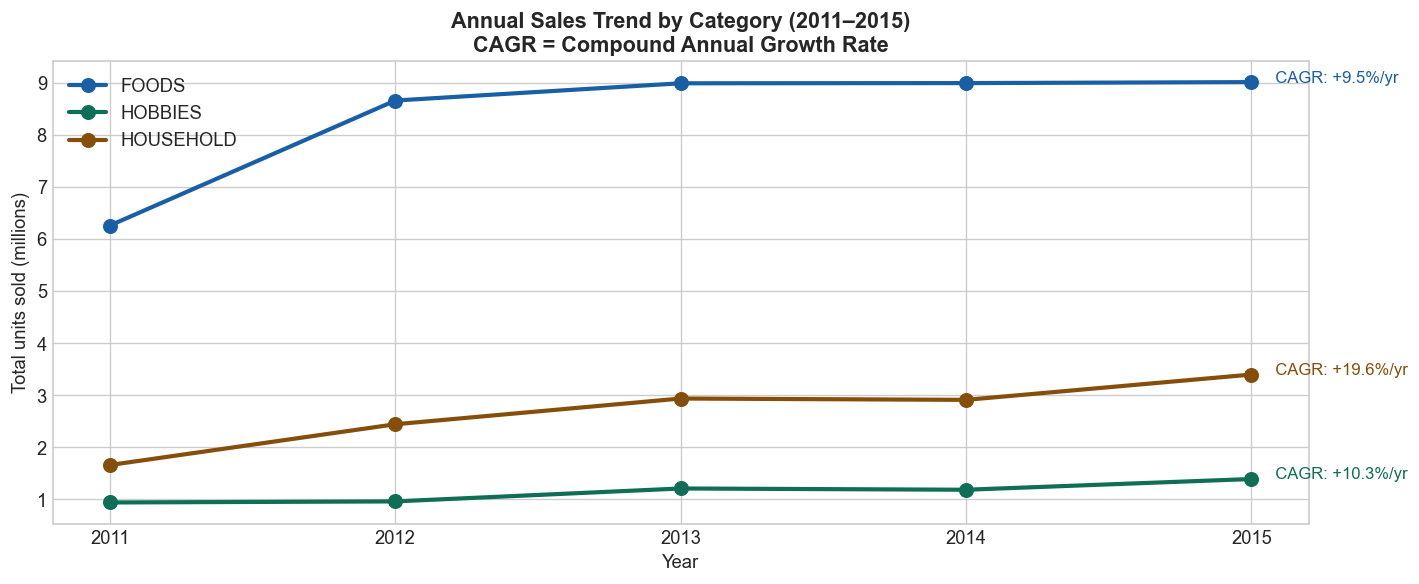

In [19]:
annual_cat = df.groupby(['year','cat_id'])['sales'].sum().reset_index()
# Only full years (2011–2015; 2016 is partial)
annual_cat = annual_cat[annual_cat['year'] <= 2015]

fig, ax = plt.subplots(figsize=(12, 5))

for cat, colour in CAT_COLOURS.items():
    cat_data = annual_cat[annual_cat['cat_id']==cat]
    ax.plot(cat_data['year'], cat_data['sales']/1e6,
            marker='o', color=colour, linewidth=2.5,
            markersize=8, label=cat)

    # Calculate CAGR (Compound Annual Growth Rate)
    first = cat_data['sales'].iloc[0]
    last  = cat_data['sales'].iloc[-1]
    n_years = len(cat_data) - 1
    cagr = (last/first)**(1/n_years) - 1
    ax.text(cat_data['year'].iloc[-1]+0.05,
            cat_data['sales'].iloc[-1]/1e6,
            f'  CAGR: +{cagr*100:.1f}%/yr',
            fontsize=10, color=colour)

ax.set_xlabel('Year')
ax.set_ylabel('Total units sold (millions)')
ax.set_title('Annual Sales Trend by Category (2011–2015)\nCAGR = Compound Annual Growth Rate')
ax.legend()
ax.set_xticks([2011,2012,2013,2014,2015])
plt.tight_layout()
plt.savefig('../outputs/12_annual_trend.png', dpi=150, bbox_inches='tight')
plt.show()

"All three categories grew over the 2011–2015 period, but at very different rates and with different growth profiles. Foods is the largest category by volume, growing from 6.3 million to 9 million units at a CAGR of 9.5%, though most of that growth was front-loaded in 2011–2012 and the category has since plateaued — suggesting it has reached saturation in these markets. Household is the standout growth story despite its smaller base, posting the highest CAGR of 19.6% and showing continued momentum through 2015 with no signs of flattening, pointing to an expanding customer need or successful ranging decisions. Hobbies, while the smallest category, also grew steadily at 10.3% per year, with its growth accelerating slightly in later years. The divergence between Foods' early plateau and Household's sustained climb is the most strategically significant signal here — it suggests that future volume growth across the network will increasingly be driven by Household rather than Foods, and that ranging and forecasting investments should reflect this shift in category momentum."

In [26]:
print("""
====================================================
EDA SUMMARY — M5 SUPPLY CHAIN ANALYTICS PROJECT
====================================================
DATASET OVERVIEW
  - 3,049 products across 10 Walmart stores (CA, TX, WI)
  - 1,919 days of daily sales data (Jan 2011 – May 2016)
  - 3 categories: FOODS, HOBBIES, HOUSEHOLD

KEY FINDINGS

  1. INTERMITTENT DEMAND
     - 68.2% of product-store-days record zero sales
     - HOBBIES most sparse (77.3%), FOODS most active (62.0%)
     - HOBBIES_2 near-dormant at 88.5% zero rate
     - Demand is right-skewed: most SKUs sell rarely

  2. SEASONALITY
     - Strong weekly cycle: weekends +23–34% vs Monday
     - FOODS & HOUSEHOLD peak in August, trough in May/December
     - HOBBIES peaks April, troughs September (seasonal swing: 9%)
     - HOUSEHOLD has largest seasonal swing at 16%

  3. SNAP DEMAND LIFT
     - SNAP days lift FOODS demand by 10% (CA), 16% (TX), 30% (WI)
     - HOBBIES and HOUSEHOLD largely unaffected (~2–4% lift)
     - SNAP schedule is a critical forecasting feature for FOODS/WI

  4. EVENT IMPACT & CENSORED DEMAND
     - Labor Day (+23%), Super Bowl (+19%), Easter (+14%) lift demand
     - Thanksgiving/Christmas/NewYear near-zero = store closure artifact
     - Pre-event build-up: Super Bowl +8.7%, Thanksgiving -6.7% (pull-forward)
     - Closure days flagged; event proximity features added to model

  5. REVENUE CONCENTRATION
     - 41% of products generate 80% of total revenue
     - Top 10 products alone account for 5.4% of revenue
     - Long tail (59% of SKUs) contributes only 20% of revenue

  6. PRICE ELASTICITY
     - Weak price-demand relationship across all categories
     - HOUSEHOLD slope: 0.29, FOODS: 0.08, HOBBIES: ~0.00
     - High scatter suggests seasonality/events dominate over price
     - Product-level analysis needed before pricing conclusions

  7. STORE DIFFERENCES
     - CA_3 is the network volume leader (11.2M units, cv=3.24)
     - TX and WI stores show higher variability (cv up to 3.69)
     - Zero rates range from 60% (CA_3) to 72% (CA_4)
     - High-variability stores require larger safety stock buffers

  8. GROWTH TREND
     - All categories grew 2011–2015
     - FOODS CAGR: +9.5% but plateaued post-2012
     - HOUSEHOLD CAGR: +19.6% — strongest and still accelerating
     - HOBBIES CAGR: +10.3% with late-period momentum

CHARTS SAVED TO: outputs/
  02_zero_sales_analysis.png
  03_total_sales_trend.png
  04_day_of_week_patterns.png
  05_monthly_seasonality.png
  06_decomposition_foods_ca1.png
  07_snap_analysis.png
  08_event_impact.png
  09_pareto_analysis.png
  10_price_elasticity.png
  11_store_analysis.png
  12_annual_trend.png
====================================================
""")


EDA SUMMARY — M5 SUPPLY CHAIN ANALYTICS PROJECT
DATASET OVERVIEW
  - 3,049 products across 10 Walmart stores (CA, TX, WI)
  - 1,919 days of daily sales data (Jan 2011 – May 2016)
  - 3 categories: FOODS, HOBBIES, HOUSEHOLD

KEY FINDINGS

  1. INTERMITTENT DEMAND
     - 68.2% of product-store-days record zero sales
     - HOBBIES most sparse (77.3%), FOODS most active (62.0%)
     - HOBBIES_2 near-dormant at 88.5% zero rate
     - Demand is right-skewed: most SKUs sell rarely

  2. SEASONALITY
     - Strong weekly cycle: weekends +23–34% vs Monday
     - FOODS & HOUSEHOLD peak in August, trough in May/December
     - HOBBIES peaks April, troughs September (seasonal swing: 9%)
     - HOUSEHOLD has largest seasonal swing at 16%

  3. SNAP DEMAND LIFT
     - SNAP days lift FOODS demand by 10% (CA), 16% (TX), 30% (WI)
     - HOBBIES and HOUSEHOLD largely unaffected (~2–4% lift)
     - SNAP schedule is a critical forecasting feature for FOODS/WI

  4. EVENT IMPACT & CENSORED DEMAND
     - L